# Question 1: Supply Chain Beta

Does a pullback in TSMC (TSM) predict a later drawdown in NVIDIA (NVDA)?

TSMC manufactures nearly all of NVIDIA's chips, so the intuition is that trouble upstream at the foundry should show up in NVDA a few days later. This notebook tests that. 

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns


DATA = Path("../data/processed")
df = pd.read_csv(DATA / "nvidia_gfn_combined.csv", parse_dates=["date"]).sort_values("date")
print(df.shape)
df.head()

(4280, 18)


,date,nvda_close,nvda_volume,tsm_close,smh_etf_close,qqq_close,nvda_return_pct,nvda_volatility_30d,nvda_sma_50,nvda_sma_200,is_trading_day,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_avg_thumbs_up,gfn_one_star_share,gfn_negative_share,gfn_positive_share
0,2015-01-01,NaN,0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,0.50325,113680000,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-03,0.50325,0,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-04,0.50325,0,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-05,0.49475,197952000,21.740000,26.760000,101.430000,-1.689023,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN


## Keeping only days the market was open

The dataset has one row for every calendar day, which includes weekends and holidays. On days the market was closed, the prices are copied forward from the last trading day and the return is set to 0. These aren't real observations. If we left them in, a one day later comparison would sometimes be comparing Friday to Saturday instead of Friday to Monday. Because of this, we are first going to remove the non-trading days.

In [28]:
print(f"All calendar rows: {len(df)}")
print(f"Actual trading sessions: {df.is_trading_day.sum()}")
print(f"Rows with a fake 0.00% return: {(df.nvda_return_pct == 0).sum()} ({100*(df.nvda_return_pct == 0).mean():.0f}% of the file)")

# Keep only real sessions and recompute returns on that grid
td = df[df.is_trading_day == 1].copy().reset_index(drop=True)
for t in ["nvda", "tsm", "smh_etf", "qqq"]:
    td[f"{t}_ret"] = td[f"{t}_close"].pct_change() * 100

td[["date", "nvda_close", "nvda_ret", "tsm_ret", "smh_etf_ret", "qqq_ret"]].head()

All calendar rows: 4280
Actual trading sessions: 2944
Rows with a fake 0.00% return: 1342 (31% of the file)


,date,nvda_close,nvda_ret,tsm_ret,smh_etf_ret,qqq_ret
0,2015-01-02,0.50325,NaN,NaN,NaN,NaN
1,2015-01-05,0.49475,-1.689023,-2.423702,-1.780145,-1.466876
2,2015-01-06,0.47975,-3.031831,-1.747926,-2.354264,-1.340827
3,2015-01-07,0.47850,-0.260552,1.451308,1.301187,1.289099
4,2015-01-08,0.49650,3.761751,0.646052,2.493388,1.913972


## Does TSM move before NVDA?

If trouble at TSMC shows up in NVIDIA's stock later, then TSM's move today should be related to NVDA's move tomorrow or the day after. To test this, we compare NVDA's daily return with TSM's return shifted by different numbers of days:
- +1 means TSM's move from 1 trading day earlier
- 0 means the same day
- −1 means TSM's move from 1 trading day *later* (a check in the other direction)

For each shift we calculate the correlation. If TSM predicts NVDA, the positive shifts should stand out.

In [29]:
lags = range(-5, 6)
rows = []
for k in lags:
    r = td["nvda_ret"].corr(td["tsm_ret"].shift(k))
    rows.append({"lag_days": k, "correlation": r})

lag_table = pd.DataFrame(rows)
lag_table.round(3)

,lag_days,correlation
0,-5,0.027
1,-4,-0.055
2,-3,-0.021
3,-2,0.017
4,-1,-0.067
5,0,0.610
6,1,-0.085
7,2,0.023
8,3,-0.014
9,4,-0.007


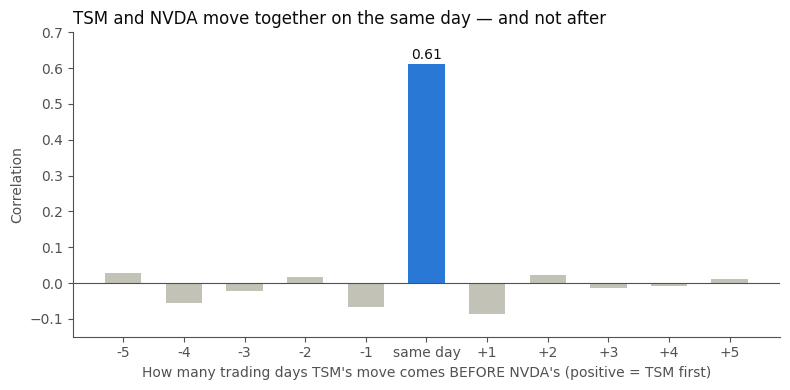

In [30]:
BLUE, GRAY, INK, MUTED = "#2a78d6", "#c3c2b7", "#0b0b0b", "#52514e"
colors = [BLUE if k == 0 else GRAY for k in lag_table.lag_days]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lag_table.lag_days, lag_table.correlation, color=colors, width=0.6)
ax.axhline(0, color=MUTED, linewidth=0.8)

ax.set_xticks(list(lags))
ax.set_xticklabels(["same day" if k == 0 else f"{k:+d}" for k in lags])
ax.set_xlabel("How many trading days TSM's move comes BEFORE NVDA's (positive = TSM first)", color=MUTED)
ax.set_ylabel("Correlation", color=MUTED)
ax.set_title("TSM and NVDA move together on the same day — and not after", loc="left", color=INK)

same = lag_table.loc[lag_table.lag_days == 0, "correlation"].iloc[0]
ax.annotate(f"{same:.2f}", (0, same), xytext=(0, 4), textcoords="offset points", ha="center", color=INK)

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color(MUTED)
ax.spines["bottom"].set_color(MUTED)
ax.tick_params(colors=MUTED)
ax.set_ylim(-0.15, 0.7)
plt.tight_layout()
plt.show()

## Is it TSMC specifically or do all chip stocks just move together?

TSM and NVDA clearly move together on the same day, but that doesn't mean TSMC is the reason. Both companies are big tech and semiconductor stocks, so they might both just be reacting to the same news (interest rates, AI hype, the overall market). This is a possible confounder that we need to check. To do this, we first look at how all four series relate to each other.

<Axes: >

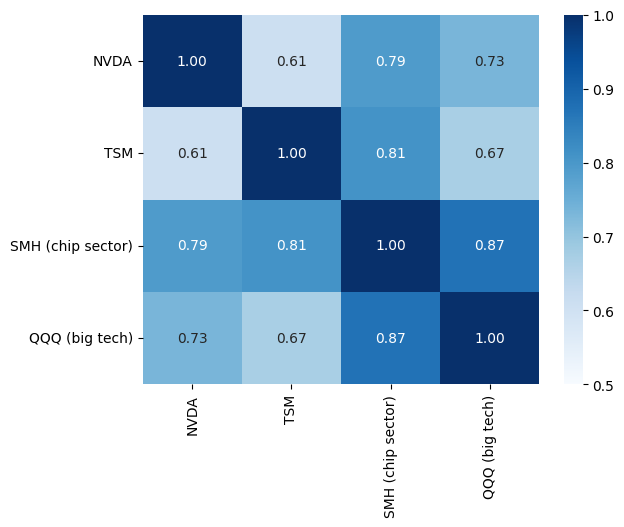

In [31]:
rets = td[["nvda_ret", "tsm_ret", "smh_etf_ret", "qqq_ret"]].dropna()
rets.columns = ["NVDA", "TSM", "SMH (chip sector)", "QQQ (big tech)"]

sns.heatmap(rets.corr(), annot=True, fmt=".2f", cmap="Blues", vmin=0.5, vmax=1)

## Removing the shared movement

Next we strip out the part of each stock's daily move that is just "the market did this today" and see if what's left of NVDA and TSM is still related. For each stock, we fit a straight line predicting its return from the market's return, then keep only the leftover since that is the part the market doesn't explain. If TSMC has its own special link to NVIDIA, the leftovers should still be correlated. We try this two ways 1. removing big tech (QQQ) and 2. removing the chip sector (SMH).

In [32]:
def leftover(stock, market):
    slope, intercept = np.polyfit(market, stock, 1)
    return stock - (slope * market + intercept)

print(f"NVDA vs TSM, raw: {rets['NVDA'].corr(rets['TSM']):.2f}")

nvda_q = leftover(rets["NVDA"], rets["QQQ (big tech)"])
tsm_q  = leftover(rets["TSM"],  rets["QQQ (big tech)"])
print(f"After removing big tech (QQQ): {nvda_q.corr(tsm_q):.2f}")

nvda_s = leftover(rets["NVDA"], rets["SMH (chip sector)"])
tsm_s  = leftover(rets["TSM"],  rets["SMH (chip sector)"])
print(f"After removing the chip sector (SMH): {nvda_s.corr(tsm_s):.2f}")

NVDA vs TSM, raw: 0.61
After removing big tech (QQQ): 0.23
After removing the chip sector (SMH): -0.09


This shows that most of the relationship between TSM and NVDA is shared movement across tech and chip stocks and not a special link with TSMC. A possible limitation is that SMH holds both NVDA and TSM as top positions, so removing it partly removes the two stocks from themselves. The drop to near zero is therefore somewhat overstated. The QQQ result
(0.61 to 0.23) is the cleaner comparison.

## What does NVDA do after a big TSM drop?

The research question asks whether TSM pullbacks lead to NVDA drops, so we look directly at the days when TSM fell 3% or more and check what NVDA did over the next 1, 5, and 10 trading days. To know whether that's unusual, we compare it to NVDA's average return over the same number of days on any day. We do the same for SMH to see whether any effect is specific to NVIDIA or shared by the whole chip sector.

In [33]:
drop_days = td.index[td["tsm_ret"] <= -3]
print(f"Days TSM fell 3% or more: {len(drop_days)}")

def forward_return(prices, h):
    return (prices.shift(-h) / prices - 1) * 100

rows = []
for h in [1, 5, 10]:
    nvda_fwd = forward_return(td["nvda_close"], h)
    smh_fwd  = forward_return(td["smh_etf_close"], h)
    rows.append({
        "days later": h,
        "NVDA after TSM drop": nvda_fwd[drop_days].mean(),
        "NVDA on a normal day": nvda_fwd.mean(),
        "SMH after TSM drop": smh_fwd[drop_days].mean(),
        "SMH on a normal day": smh_fwd.mean(),
    })

results = pd.DataFrame(rows).set_index("days later")
results.round(2)

Days TSM fell 3% or more: 169


,NVDA after TSM drop,NVDA on a normal day,SMH after TSM drop,SMH on a normal day
days later,,,,
1,1.09,0.25,0.79,0.12
5,1.77,1.25,1.30,0.60
10,4.00,2.52,2.38,1.20


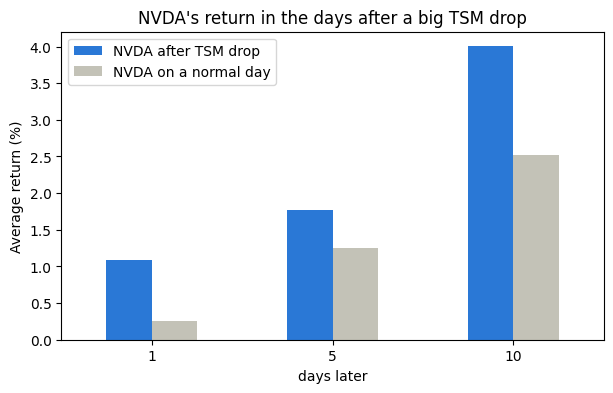

In [34]:
results[["NVDA after TSM drop", "NVDA on a normal day"]].plot.bar(
    color=["#2a78d6", "#c3c2b7"], rot=0, figsize=(7, 4))
plt.ylabel("Average return (%)")
plt.title("NVDA's return in the days after a big TSM drop")
plt.show()

This shows that after TSM falls 3% or more, NVDA does not drop further. It tends to go up more than usual, which is the opposite of what the research question expected. SMH does the same thing. After a big TSM drop, the whole chip sector tends to bounce back. NVDA's bounce is a bit bigger, which fits with NVDA generally moving more than the sector in both directions.

Thus, a TSM drop is not an early warning for NVIDIA. By the time TSM has dropped, NVDA has usually dropped on the same day too and afterward the sector recovers together.

## Engineered features

The raw data gives daily prices. To study the question better, we build four new features from them:

1. `nvda_tsm_corr_60d`: the correlation between NVDA and TSM over the previous 60 trading days. Shows whether the link changes over time
2. `nvda_drawdown`: how far NVDA is below its highest price so far, in %. The research question asks about drawdowns, so we measure them directly
3. `tsm_drawdown`: the same thing for TSM
4. `tsm_big_drop`: 1 if TSM fell 3% or more that day, otherwise 0. This is the event we used in the previous section

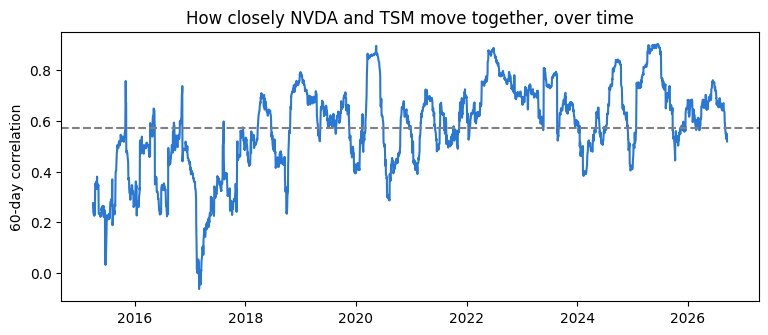

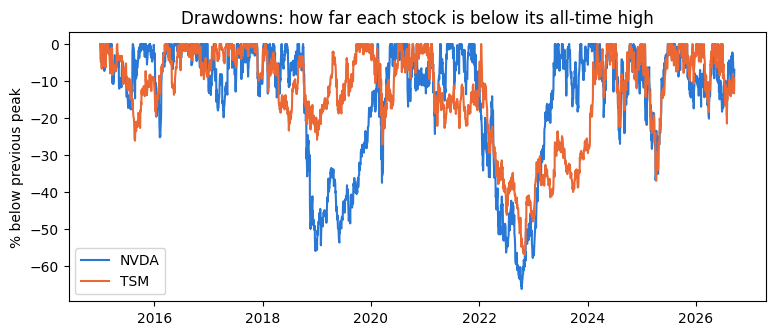

In [35]:
td["nvda_tsm_corr_60d"] = td["nvda_ret"].rolling(60).corr(td["tsm_ret"])
td["nvda_drawdown"] = (td["nvda_close"] / td["nvda_close"].cummax() - 1) * 100
td["tsm_drawdown"]  = (td["tsm_close"]  / td["tsm_close"].cummax()  - 1) * 100
td["tsm_big_drop"]  = (td["tsm_ret"] <= -3).astype(int)

td[["date", "nvda_tsm_corr_60d", "nvda_drawdown", "tsm_drawdown", "tsm_big_drop"]].tail()

plt.figure(figsize=(9, 3.5))
plt.plot(td["date"], td["nvda_tsm_corr_60d"], color="#2a78d6")
plt.axhline(td["nvda_tsm_corr_60d"].mean(), color="gray", linestyle="--")
plt.ylabel("60-day correlation")
plt.title("How closely NVDA and TSM move together, over time")
plt.show()

plt.figure(figsize=(9, 3.5))
plt.plot(td["date"], td["nvda_drawdown"], color="#2a78d6", label="NVDA")
plt.plot(td["date"], td["tsm_drawdown"],  color="#eb6834", label="TSM")
plt.ylabel("% below previous peak")
plt.title("Drawdowns: how far each stock is below its all-time high")
plt.legend()
plt.show()

Conclusions from the plots:
1. The 60-day correlation moves around a lot (from near 0 in early 2017 to about 0.9 at its highest) averaging 0.57. The link between the two stocks isn't a fixed property. It depends on the period.
2. NVDA's two biggest drops were in late 2018 (about −56%) and 2022 (−66%). In 2022, TSM fell at the same time (−57%). However, in 2018, TSM only fell about 20% while NVDA lost more than half its value, meaning NVIDIA's worst crash in that period happened without a matching crash at TSMC.

## Summary of findings
The answer to our research question of "Do pullbacks in TSMC (TSM) predict later drawdowns in NVIDIA (NVDA)?" is no. In this data, TSM is not an early warning for NVDA.

Reasoning:

1. There's no delay between the two stocks. TSM and NVDA move together on the same day (correlation 0.61), but TSM's move says nothing about what NVDA does 1 to 5 trading days later.
2. Most of the connection is shared movement across the market. NVDA tracks the chip sector (0.79) and big tech (0.73) more closely than it tracks TSM, and after removing big tech's daily moves, the TSM–NVDA link falls from 0.61 to 0.23.
3. NVDA doesn't drop after a TSM drop. After TSM falls 3% or more, NVDA tends to rise over the next 1 to 10 days but so does the whole chip sector.
4. The two stocks don't always crash together. In 2018, NVDA fell about 56% from its peak while TSM fell only about 20%, so NVIDIA's big drops don't require a TSMC one.

Limitations:

1. TSM here is the US-listed version of TSMC, which trades during the same hours as NVDA. That makes a delay hard to detect by design.
2. Stock prices are a rough stand-in for supply disruptions. A real supply problem might not show up in the stock price at all.
3. The SMH chip-sector fund holds both NVDA and TSM, which makes it harder to separate a TSMC-specific effect.